# Logistic Regression — MobileNetV2 Features

This notebook follows the uploaded reference notebook's approach:

**MobileNetV2 CNN features → StandardScaler → Logistic Regression → C tuning**

It uses the feature files produced by `01_dataset_preprocessing.ipynb`.


## 1. Imports and paths


In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score
)

SEED = 42

PROJECT_ROOT = Path.cwd().parent
if not (PROJECT_ROOT / "results").exists():
    PROJECT_ROOT = Path.cwd()

DATA_DIR = PROJECT_ROOT / "data"
RESULTS_DIR = PROJECT_ROOT / "results"

print("Project:", PROJECT_ROOT)


Project: c:\Users\Noothan\Documents\my_work\structural-damage-classification


## 2. Load MobileNetV2 features and labels


In [2]:
X_train = np.load(RESULTS_DIR / "X_train_mobilenetv2.npy")
X_val = np.load(RESULTS_DIR / "X_val_mobilenetv2.npy")
X_test = np.load(RESULTS_DIR / "X_test_mobilenetv2.npy")

y_train_raw = np.load(
    DATA_DIR / "task2_damage_state_1" / "task2_y_train.npy"
)
y_test_raw = np.load(
    DATA_DIR / "task2_damage_state_1" / "task2_y_test.npy"
)

y_train_all = np.argmax(y_train_raw, axis=1) if y_train_raw.ndim > 1 else y_train_raw
y_test = np.argmax(y_test_raw, axis=1) if y_test_raw.ndim > 1 else y_test_raw

from sklearn.model_selection import train_test_split

indices = np.arange(len(y_train_all))
train_idx, val_idx = train_test_split(
    indices,
    test_size=0.15,
    random_state=SEED,
    stratify=y_train_all
)

y_train = y_train_all[train_idx]
y_val = y_train_all[val_idx]

print("X_train:", X_train.shape)
print("X_val  :", X_val.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_val  :", y_val.shape)
print("y_test :", y_test.shape)


X_train: (10039, 1280)
X_val  : (1772, 1280)
X_test : (1460, 1280)
y_train: (10039,)
y_val  : (1772,)
y_test : (1460,)


## 3. Verify alignment


In [3]:
assert X_train.shape[0] == len(y_train)
assert X_val.shape[0] == len(y_val)
assert X_test.shape[0] == len(y_test)

print("✓ Features and labels match.")


✓ Features and labels match.


## 4. StandardScaler

The scaler is fitted **only on the training features**, then applied to validation and test features.


In [4]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("✓ StandardScaler fitted on training data only.")
print("Scaled feature shape:", X_train_scaled.shape)


✓ StandardScaler fitted on training data only.
Scaled feature shape: (10039, 1280)


## 5. Logistic Regression with C tuning

The uploaded reference notebook tested **C = 0.1, 1, 10**. We use the same values. Three-fold CV is used here to keep runtime practical on a 10k-image dataset.


In [5]:
cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=SEED
)

lr = LogisticRegression(
    max_iter=1000,
    solver="lbfgs",
    random_state=SEED
)

param_grid = {
    "C": [0.1, 1.0, 10.0]
}

print("Training Logistic Regression with GridSearchCV...")

grid = GridSearchCV(
    estimator=lr,
    param_grid=param_grid,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1,
    error_score="raise"
)

grid.fit(X_train_scaled, y_train)

best_lr = grid.best_estimator_

print("✓ Training completed.")
print("Best C:", grid.best_params_["C"])
print("Best CV accuracy:", f"{grid.best_score_:.4f}")


Training Logistic Regression with GridSearchCV...
✓ Training completed.
Best C: 0.1
Best CV accuracy: 0.7804


## 6. Validation evaluation


In [6]:
y_val_pred = best_lr.predict(X_val_scaled)

print(f"Validation Accuracy : {accuracy_score(y_val, y_val_pred):.4f}")
print(f"Validation Precision: {precision_score(y_val, y_val_pred, zero_division=0):.4f}")
print(f"Validation Recall   : {recall_score(y_val, y_val_pred, zero_division=0):.4f}")
print(f"Validation F1       : {f1_score(y_val, y_val_pred, zero_division=0):.4f}")

print("\nValidation Classification Report:")
print(classification_report(
    y_val, y_val_pred,
    target_names=["Class 0", "Class 1"],
    zero_division=0
))


Validation Accuracy : 0.7822
Validation Precision: 0.7540
Validation Recall   : 0.7940
Validation F1       : 0.7735

Validation Classification Report:
              precision    recall  f1-score   support

     Class 0       0.81      0.77      0.79       942
     Class 1       0.75      0.79      0.77       830

    accuracy                           0.78      1772
   macro avg       0.78      0.78      0.78      1772
weighted avg       0.78      0.78      0.78      1772



## 7. Final test evaluation


In [7]:
y_test_pred = best_lr.predict(X_test_scaled)

test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred, zero_division=0)
test_recall = recall_score(y_test, y_test_pred, zero_division=0)
test_f1 = f1_score(y_test, y_test_pred, zero_division=0)

print(f"Test Accuracy : {test_accuracy:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall   : {test_recall:.4f}")
print(f"Test F1       : {test_f1:.4f}")

print("\nTest Classification Report:")
print(classification_report(
    y_test, y_test_pred,
    target_names=["Class 0", "Class 1"],
    zero_division=0
))


Test Accuracy : 0.7781
Test Precision: 0.7773
Test Recall   : 0.7664
Test F1       : 0.7718

Test Classification Report:
              precision    recall  f1-score   support

     Class 0       0.78      0.79      0.78       745
     Class 1       0.78      0.77      0.77       715

    accuracy                           0.78      1460
   macro avg       0.78      0.78      0.78      1460
weighted avg       0.78      0.78      0.78      1460



## 8. Confusion matrix


Confusion Matrix:
[[588 157]
 [167 548]]


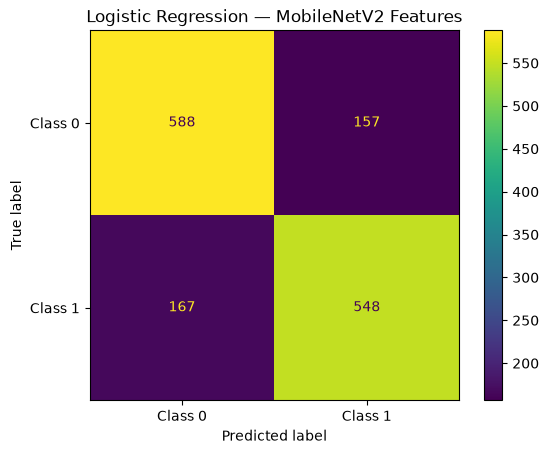

In [8]:
cm = confusion_matrix(y_test, y_test_pred)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Class 0", "Class 1"]
)
disp.plot()
plt.title("Logistic Regression — MobileNetV2 Features")
plt.show()


## 9. ROC-AUC


Test ROC-AUC: 0.8720


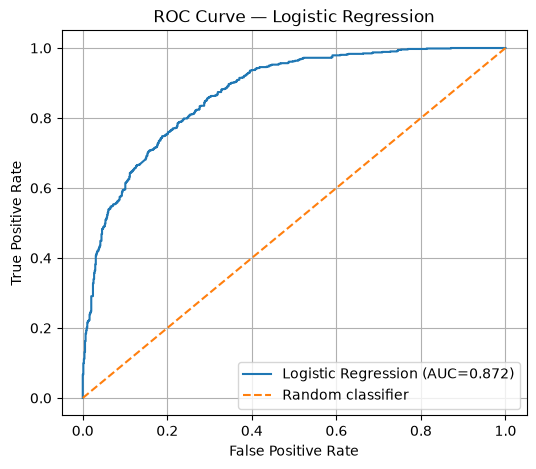

In [9]:
y_test_prob = best_lr.predict_proba(X_test_scaled)[:, 1]
test_auc = roc_auc_score(y_test, y_test_prob)
fpr, tpr, _ = roc_curve(y_test, y_test_prob)

print(f"Test ROC-AUC: {test_auc:.4f}")

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC={test_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Logistic Regression")
plt.legend()
plt.grid(True)
plt.show()


## 10. Save model and scaler


In [10]:
import joblib

MODEL_DIR = PROJECT_ROOT / "models"
MODEL_DIR.mkdir(exist_ok=True)

joblib.dump(best_lr, MODEL_DIR / "logistic_regression_mobilenetv2.pkl")
joblib.dump(scaler, MODEL_DIR / "mobilenetv2_scaler.pkl")

print("✓ Saved Logistic Regression model.")
print("✓ Saved StandardScaler.")


✓ Saved Logistic Regression model.
✓ Saved StandardScaler.
